# 전자상거래 배송 지연 분석 — 룰베이스 분류 도출

## 분석 시나리오
한 국제 전자상거래 회사가 전자제품을 판매한다. 최근 배송 지연이 많아져 고객 불만이 쌓이고 있다.
당신은 데이터 분석 담당자로서 **어떤 조건에서 지연이 발생하는지** 찾아내고, 단순한 룰만으로 지연 가능성을 예측할 수 있는지 확인해야 한다.

## 분석 흐름
1. **데이터 파악** — 컬럼, 타입, 분포 확인
2. **시각화 탐색**  — 단변량/타겟별 분포 비교
3. **인사이트 정리**  — 강한 시그널 vs 약한 시그널
4. **룰 도출 및 검증**  — 룰1, 룰2 정의 후 정확도/혼동행렬 확인
5. **잔여 영역 심화 분석**  — 잔여 영역에서 룰3 발견 + 3개 룰 종합 평가

## 데이터
- 파일: `배송데이터_전체.csv` (10,999행, 11개 컬럼)
- 타겟: `배송결과` (`지연` / `정시`)

---

## 0. 환경 준비

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 자동 감지 (환경에 설치된 첫 번째 한글 폰트 사용)
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
              'Noto Sans CJK KR', 'Noto Sans KR', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
for font in candidates:
    if font in available:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
pd.set_option('display.max_columns', None)

---
## 1. 데이터 파악

### 과제 1-1. 데이터를 불러오고 모양과 처음 5행을 확인하시오.

In [2]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv("배송데이터_전체.csv")

# 데이터 형태 확인
print("데이터 크기:", df.shape)

# 처음 5행 확인
print(df.head())

데이터 크기: (10999, 11)
  창고블록 배송수단  문의전화수  고객평점  상품가격  이전구매횟수 상품중요도 성별  할인율  무게_그램 배송결과
0    D   항공      4     2   177       3     하  여   44   1233   지연
1    F   항공      4     5   216       2     하  남   59   3088   지연
2    A   항공      2     2   183       4     하  남   48   3374   지연
3    B   항공      3     3   176       4     중  남   10   1177   지연
4    C   항공      2     2   184       3     중  여   46   2484   지연


**해석:**  총 10,999건, 11개 변수로 구성된 배송 운영 데이터이며 배송결과(정시/지연)를 예측·분석하기에 충분한 규모입니다.
물류(창고블록, 배송수단, 무게), 고객(평점, 이전구매횟수), 프로모션(할인율) 정보가 함께 포함되어 있어 지연 원인 분석에 적합합니다.
초기 샘플에서는 할인율이 높은 주문에서 지연이 자주 보이며, 항공배송에서도 지연이 발생해 단순 운송 문제가 아닐 가능성이 있습니다.

### 과제 1-2. 각 컬럼의 데이터 타입과 결측치를 확인하시오.

In [3]:
# 컬럼별 데이터 타입 확인
print(df.dtypes)

print("\n" + "="*50 + "\n")

# 컬럼별 결측치 개수 확인
print(df.isnull().sum())

창고블록        str
배송수단        str
문의전화수     int64
고객평점      int64
상품가격      int64
이전구매횟수    int64
상품중요도       str
성별          str
할인율       int64
무게_그램     int64
배송결과        str
dtype: object


창고블록      0
배송수단      0
문의전화수     0
고객평점      0
상품가격      0
이전구매횟수    0
상품중요도     0
성별        0
할인율       0
무게_그램     0
배송결과      0
dtype: int64


**해석:** 
- 모든 컬럼에 결측치가 존재하지 않아 별도의 결측치 처리 없이 바로 EDA를 진행할 수 있습니다.
- 범주형 변수(str)와 수치형 변수(int64)가 명확히 구분되어 있어 시각화 및 그룹 분석에 적합한 구조입니다.
- 배송결과를 기준으로 물류, 고객, 프로모션 변수 간 관계를 분석하기 좋은 품질의 데이터입니다.

### 과제 1-3. 수치형 변수의 기초 통계량을 확인하시오.

In [4]:
# 수치형 변수 기초 통계량 확인
df.describe()

,문의전화수,고객평점,상품가격,이전구매횟수,할인율,무게_그램
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000


**해석:** 
- 할인율은 평균 13.37%이지만 최대 65%까지 존재하여 일부 강한 프로모션 주문이 포함되어 있습니다.
- 상품 무게는 평균 약 3.6kg이며 최소 1kg~최대 7.8kg까지 분포해 다양한 배송 난이도를 가진 데이터로 보입니다.
- 이전구매횟수와 고객평점 분포를 통해 신규/충성 고객에 따른 배송 품질 차이를 분석할 수 있습니다.

### 과제 1-4. 타겟 변수 `배송결과`의 분포를 확인하시오. 클래스 불균형이 있는지 평가하시오.

배송결과
지연    6563
정시    4436
Name: count, dtype: int64


배송결과
지연    59.669061
정시    40.330939
Name: proportion, dtype: float64




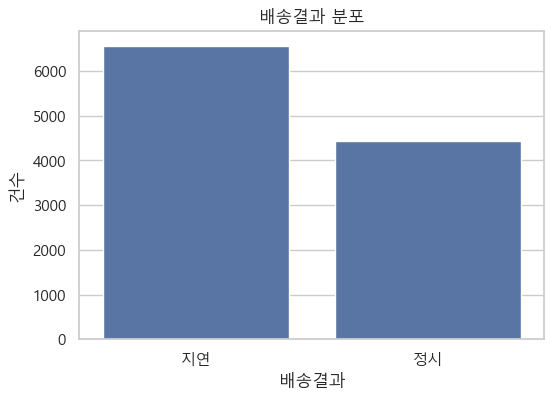

In [5]:
# 배송결과 분포 확인
result_count = df["배송결과"].value_counts()

print(result_count)

print("\n" + "="*50 + "\n")

# 비율 확인
result_ratio = df["배송결과"].value_counts(normalize=True) * 100

print(result_ratio)

print("\n" + "="*50 + "\n")

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="배송결과")

plt.title("배송결과 분포")
plt.xlabel("배송결과")
plt.ylabel("건수")

plt.show()

**해석:**
- 전체 주문 중 약 59.7%가 배송 지연으로 나타나 정시 배송보다 지연 비율이 더 높은 상태입니다.
- 클래스 비율이 6:4 수준으로 극단적인 불균형은 아니지만, 배송 지연 문제가 운영상 주요 이슈일 가능성이 큽니다.
- 따라서 이후 분석에서는 어떤 변수들이 배송 지연 증가와 연결되는지 파악하는 것이 핵심입니다.


### 과제 1-5. 범주형 변수의 카테고리별 빈도를 시각화하여 확인하시오.


[창고블록 카테고리별 빈도]
창고블록
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


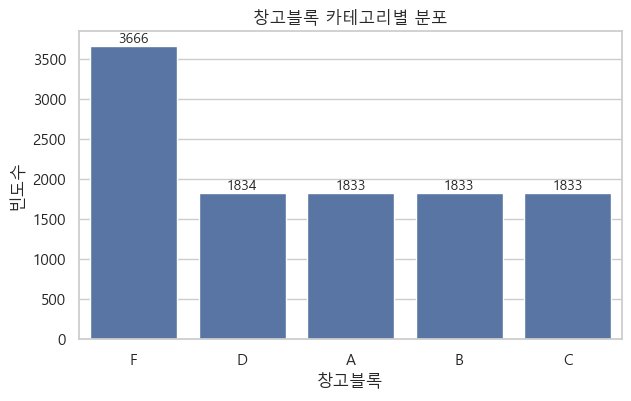


[배송수단 카테고리별 빈도]
배송수단
선박    7462
항공    1777
육로    1760
Name: count, dtype: int64


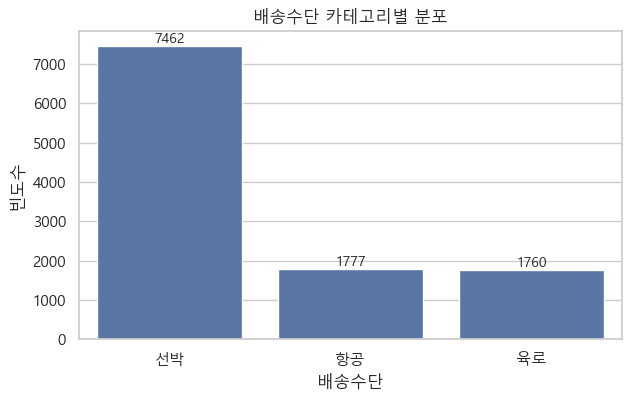


[상품중요도 카테고리별 빈도]
상품중요도
하    5297
중    4754
상     948
Name: count, dtype: int64


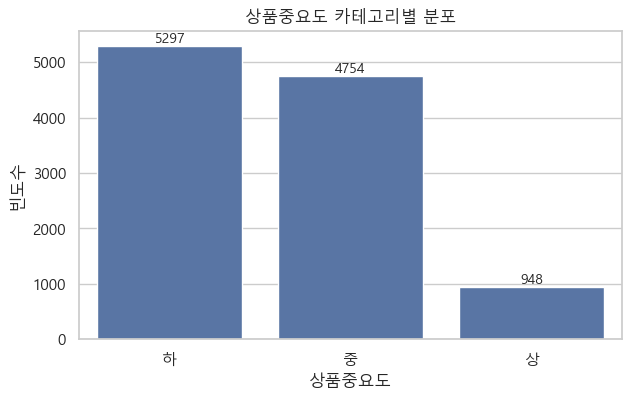


[성별 카테고리별 빈도]
성별
여    5545
남    5454
Name: count, dtype: int64


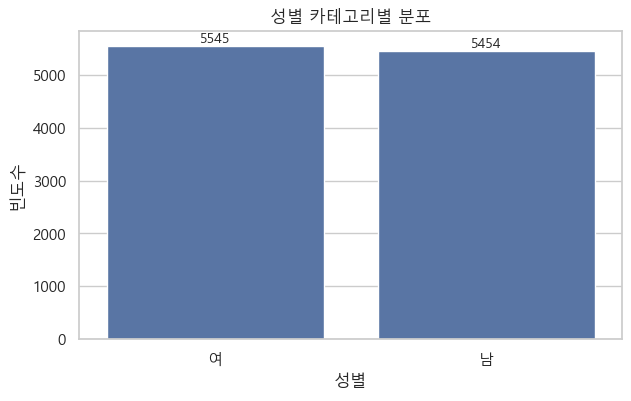


[배송결과 카테고리별 빈도]
배송결과
지연    6563
정시    4436
Name: count, dtype: int64


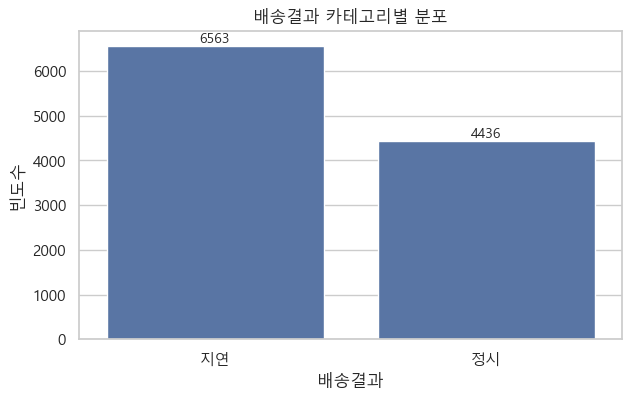

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 범주형 변수 선택
cat_cols = ["창고블록", "배송수단", "상품중요도", "성별", "배송결과"]

# 스타일 설정
# sns.set_style("whitegrid")

# 반복 시각화
for col in cat_cols:
    
    # 카테고리별 개수 계산
    count_data = df[col].value_counts()

    # 수치 출력
    print(f"\n[{col} 카테고리별 빈도]")
    print(count_data)

    # 그래프 생성
    plt.figure(figsize=(7,4))

    ax = sns.countplot(
        data=df,
        x=col,
        order=count_data.index
    )

    # 막대 위 수치 표시
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.title(f"{col} 카테고리별 분포")
    plt.xlabel(col)
    plt.ylabel("빈도수")

    plt.show()

**해석:**

- 창고블록은 F 구역의 주문량이 다른 블록보다 약 2배 많아 물류 집중 또는 허브 창고 역할 가능성이 있습니다.
- 배송수단은 선박 비중이 매우 높아(약 68%) 전체 배송 품질에 선박 운영 효율이 큰 영향을 줄 것으로 보입니다.
- 상품은 ‘하’ 중요도 비중이 가장 높으며, 성별 분포는 남녀가 거의 균형적이라 성별 편향은 크지 않은 데이터입니다.
- 배송결과에서는 지연 비율이 더 높게 나타나 현재 물류 운영 안정성 개선이 필요한 상태로 해석됩니다.


---
## 2. 시각화 탐색

이제 각 피처가 `배송결과`와 어떤 관계가 있는지 살펴본다. 강한 관계가 있는 피처는 룰의 후보가 된다.

### 과제 2-1. 수치형 변수들의 분포(히스토그램)를 한눈에 보시오.


[문의전화수]

기초 통계량
- 평균: 4.05
- 중앙값: 4.00
- 표준편차: 1.14

분포 특성
- 왜도(skewness): 0.39
- 첨도(kurtosis): -0.31
- KDE 기반 봉우리 개수: 4
- 분포 형태: 다봉분포
- 왜도 해석: 대칭에 가까움

KDE Peak 위치
- 3.00
- 4.00
- 5.00
- 6.00

최빈 구간(top peak)
- 4.0 ~ 4.5 : 3557

상위 3개 밀집구간
- 4.0 ~ 4.5 : 3557
- 3.0 ~ 3.5 : 3217
- 5.0 ~ 5.5 : 2328

희소구간(gap)
- 2.5 ~ 3.0 : 0
- 3.5 ~ 4.0 : 0
- 4.5 ~ 5.0 : 0
- 5.5 ~ 6.0 : 0
- 6.5 ~ 7.0 : 246

이상치 비율(IQR 기준)
- 0.00%

Histogram Bin Counts
2.00 ~ 2.50 : 638
2.50 ~ 3.00 : 0
3.00 ~ 3.50 : 3217
3.50 ~ 4.00 : 0
4.00 ~ 4.50 : 3557
4.50 ~ 5.00 : 0
5.00 ~ 5.50 : 2328
5.50 ~ 6.00 : 0
6.00 ~ 6.50 : 1013
6.50 ~ 7.00 : 246

[고객평점]

기초 통계량
- 평균: 2.99
- 중앙값: 3.00
- 표준편차: 1.41

분포 특성
- 왜도(skewness): 0.00
- 첨도(kurtosis): -1.30
- KDE 기반 봉우리 개수: 3
- 분포 형태: 다봉분포
- 왜도 해석: 대칭에 가까움

KDE Peak 위치
- 2.00
- 3.00
- 4.00

최빈 구간(top peak)
- 3.0 ~ 3.4 : 2239

상위 3개 밀집구간
- 3.0 ~ 3.4 : 2239
- 1.0 ~ 1.4 : 2235
- 3.8 ~ 4.2 : 2189

희소구간(gap)
- 1.4 ~ 1.8 : 0
- 2.2 ~ 2.6 : 0
- 2.6 ~ 3.0 : 0
- 3.4 ~ 3.8 : 0
- 4.2 ~ 4.6 : 0

이상치

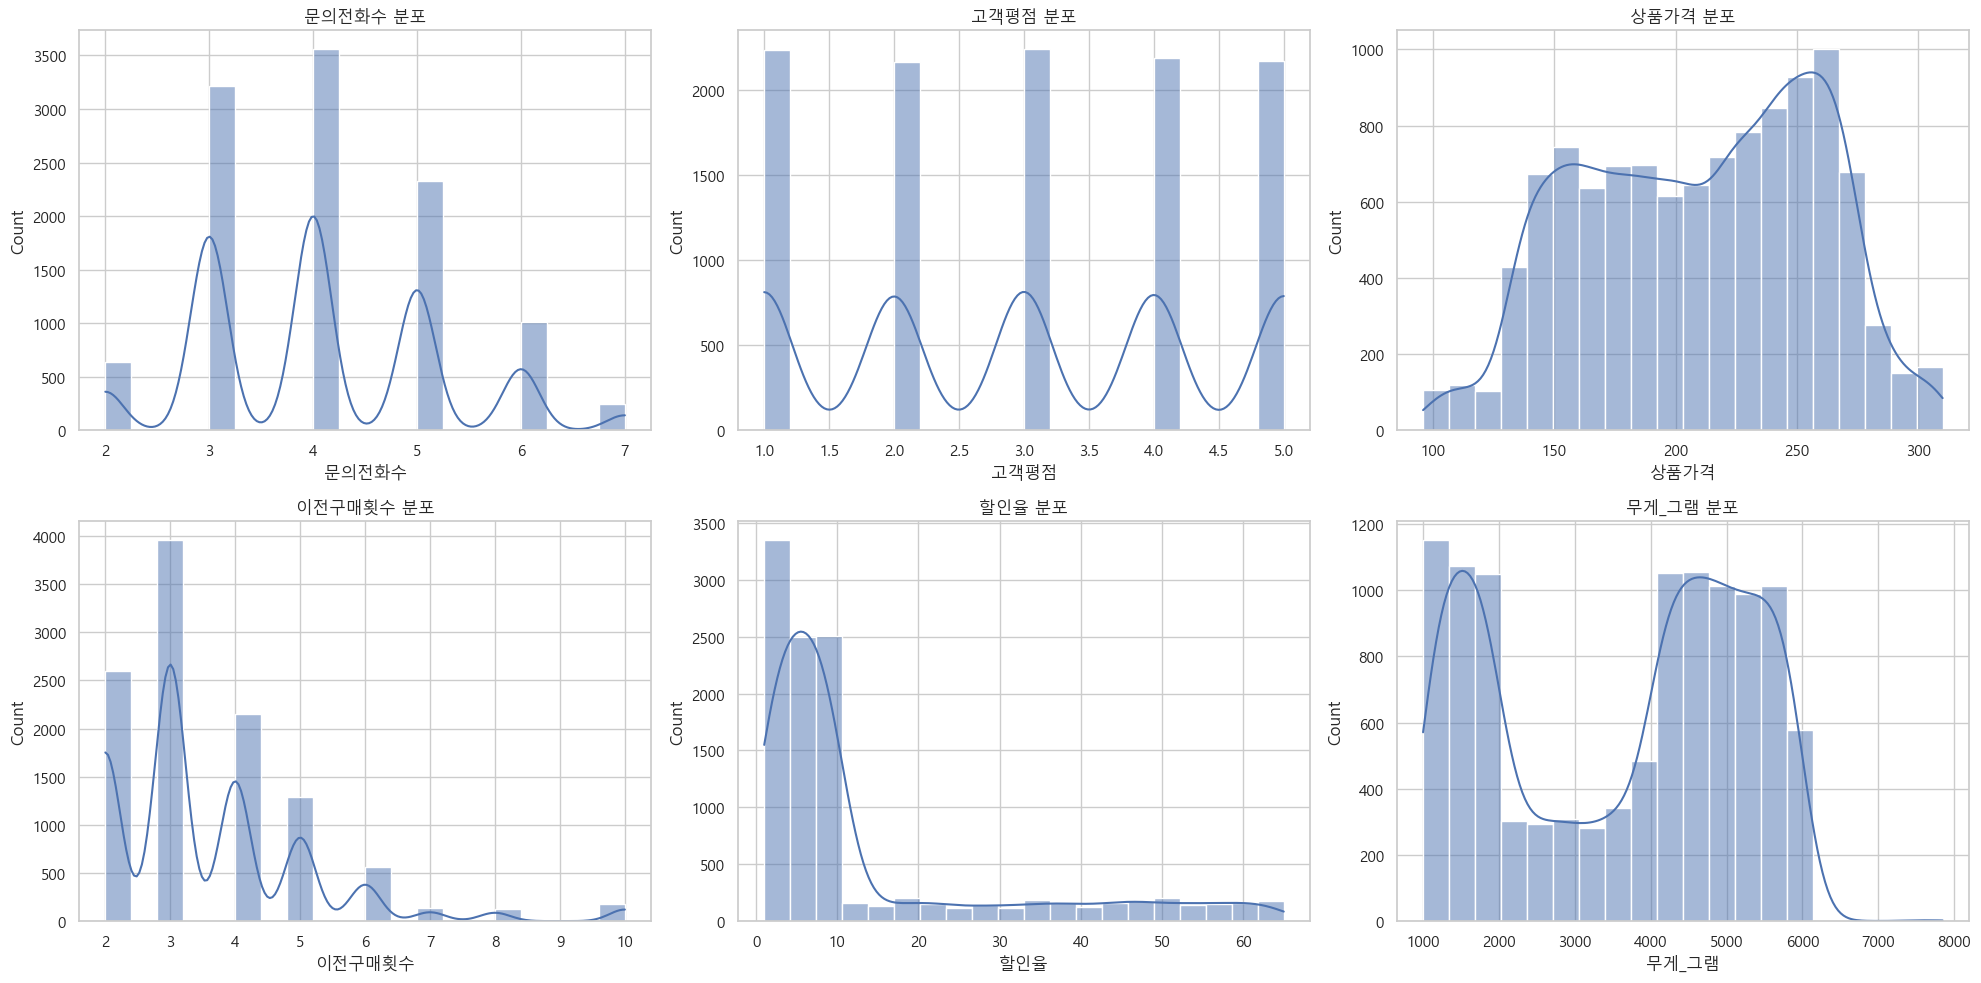

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, gaussian_kde
from scipy.signal import find_peaks

# 수치형 변수 선택
num_cols = [
    "문의전화수",
    "고객평점",
    "상품가격",
    "이전구매횟수",
    "할인율",
    "무게_그램"
]

# subplot 설정
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

# 반복 분석
for i, col in enumerate(num_cols):

    data = df[col]

    # ---------------------------------------------------
    # 히스토그램 + KDE 시각화
    # ---------------------------------------------------
    sns.histplot(
        data,
        bins=20,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} 분포")

    # ---------------------------------------------------
    # 기초 통계량
    # ---------------------------------------------------
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()

    skew_val = skew(data)
    kurt_val = kurtosis(data)

    # ---------------------------------------------------
    # Histogram Bin
    # ---------------------------------------------------
    counts, bin_edges = np.histogram(
        data,
        bins=10
    )

    # 최빈구간
    top_idx = np.argmax(counts)

    top_peak = (
        round(bin_edges[top_idx], 2),
        round(bin_edges[top_idx + 1], 2),
        counts[top_idx]
    )

    # ---------------------------------------------------
    # 상위 3개 밀집구간
    # ---------------------------------------------------
    top3_idx = np.argsort(counts)[-3:][::-1]

    top3_bins = []

    for idx in top3_idx:
        top3_bins.append(
            (
                round(bin_edges[idx], 2),
                round(bin_edges[idx + 1], 2),
                counts[idx]
            )
        )

    # ---------------------------------------------------
    # 희소구간(gap)
    # ---------------------------------------------------
    sparse_bins = []

    sparse_threshold = counts.mean() * 0.3

    for j in range(len(counts)):
        if counts[j] < sparse_threshold:
            sparse_bins.append(
                (
                    round(bin_edges[j], 2),
                    round(bin_edges[j + 1], 2),
                    counts[j]
                )
            )

    # ---------------------------------------------------
    # 이상치 비율(IQR)
    # ---------------------------------------------------
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_ratio = (
        ((data < lower) | (data > upper)).mean()
    ) * 100

    # ---------------------------------------------------
    # KDE 기반 Peak Detection
    # ---------------------------------------------------
    x = np.linspace(
        data.min(),
        data.max(),
        1000
    )

    kde = gaussian_kde(data)

    y = kde(x)

    # prominence는 peak 민감도 조절
    peaks, properties = find_peaks(
        y,
        prominence=y.max() * 0.05
    )

    peak_positions = x[peaks]

    peak_count = len(peak_positions)

    # ---------------------------------------------------
    # 다봉성 판별
    # ---------------------------------------------------
    if peak_count >= 3:
        modality = "다봉분포"
    elif peak_count == 2:
        modality = "이봉분포"
    else:
        modality = "단봉분포"

    # ---------------------------------------------------
    # 왜도 해석
    # ---------------------------------------------------
    if skew_val > 1:
        skew_desc = "강한 우측왜도"
    elif skew_val > 0.5:
        skew_desc = "우측왜도"
    elif skew_val < -1:
        skew_desc = "강한 좌측왜도"
    elif skew_val < -0.5:
        skew_desc = "좌측왜도"
    else:
        skew_desc = "대칭에 가까움"

    # ---------------------------------------------------
    # 결과 출력
    # ---------------------------------------------------
    print("\n" + "="*80)
    print(f"[{col}]")

    print("\n기초 통계량")
    print(f"- 평균: {mean_val:.2f}")
    print(f"- 중앙값: {median_val:.2f}")
    print(f"- 표준편차: {std_val:.2f}")

    print("\n분포 특성")
    print(f"- 왜도(skewness): {skew_val:.2f}")
    print(f"- 첨도(kurtosis): {kurt_val:.2f}")
    print(f"- KDE 기반 봉우리 개수: {peak_count}")
    print(f"- 분포 형태: {modality}")
    print(f"- 왜도 해석: {skew_desc}")

    print("\nKDE Peak 위치")
    for p in peak_positions:
        print(f"- {p:.2f}")

    print("\n최빈 구간(top peak)")
    print(
        f"- {top_peak[0]} ~ {top_peak[1]} "
        f": {top_peak[2]}"
    )

    print("\n상위 3개 밀집구간")
    for b in top3_bins:
        print(
            f"- {b[0]} ~ {b[1]} : {b[2]}"
        )

    print("\n희소구간(gap)")
    if len(sparse_bins) == 0:
        print("- 없음")
    else:
        for s in sparse_bins:
            print(
                f"- {s[0]} ~ {s[1]} : {s[2]}"
            )

    print("\n이상치 비율(IQR 기준)")
    print(f"- {outlier_ratio:.2f}%")

    print("\nHistogram Bin Counts")
    for j in range(len(counts)):
        print(
            f"{bin_edges[j]:.2f} ~ "
            f"{bin_edges[j+1]:.2f}"
            f" : {counts[j]}"
        )

# subplot 정리
plt.tight_layout()

plt.show()

**해석:**

- 할인율은 평균 13% 수준이지만 최대 65%까지 존재하여 일부 대규모 할인 주문이 포함되어 있으며, 분포의 편차가 큰 변수로 보입니다.
- 상품가격과 무게는 범위가 넓어 저가·경량 상품부터 고가·중량 상품까지 다양한 주문 유형이 존재합니다.
- 문의전화수와 이전구매횟수는 비교적 좁은 범위에 분포하여 대부분의 고객 행동 패턴은 일정 수준에 집중되어 있습니다.


### 과제 2-2. 수치형 변수 각각에 대해 `배송결과`별 박스플롯을 그려 비교하시오.

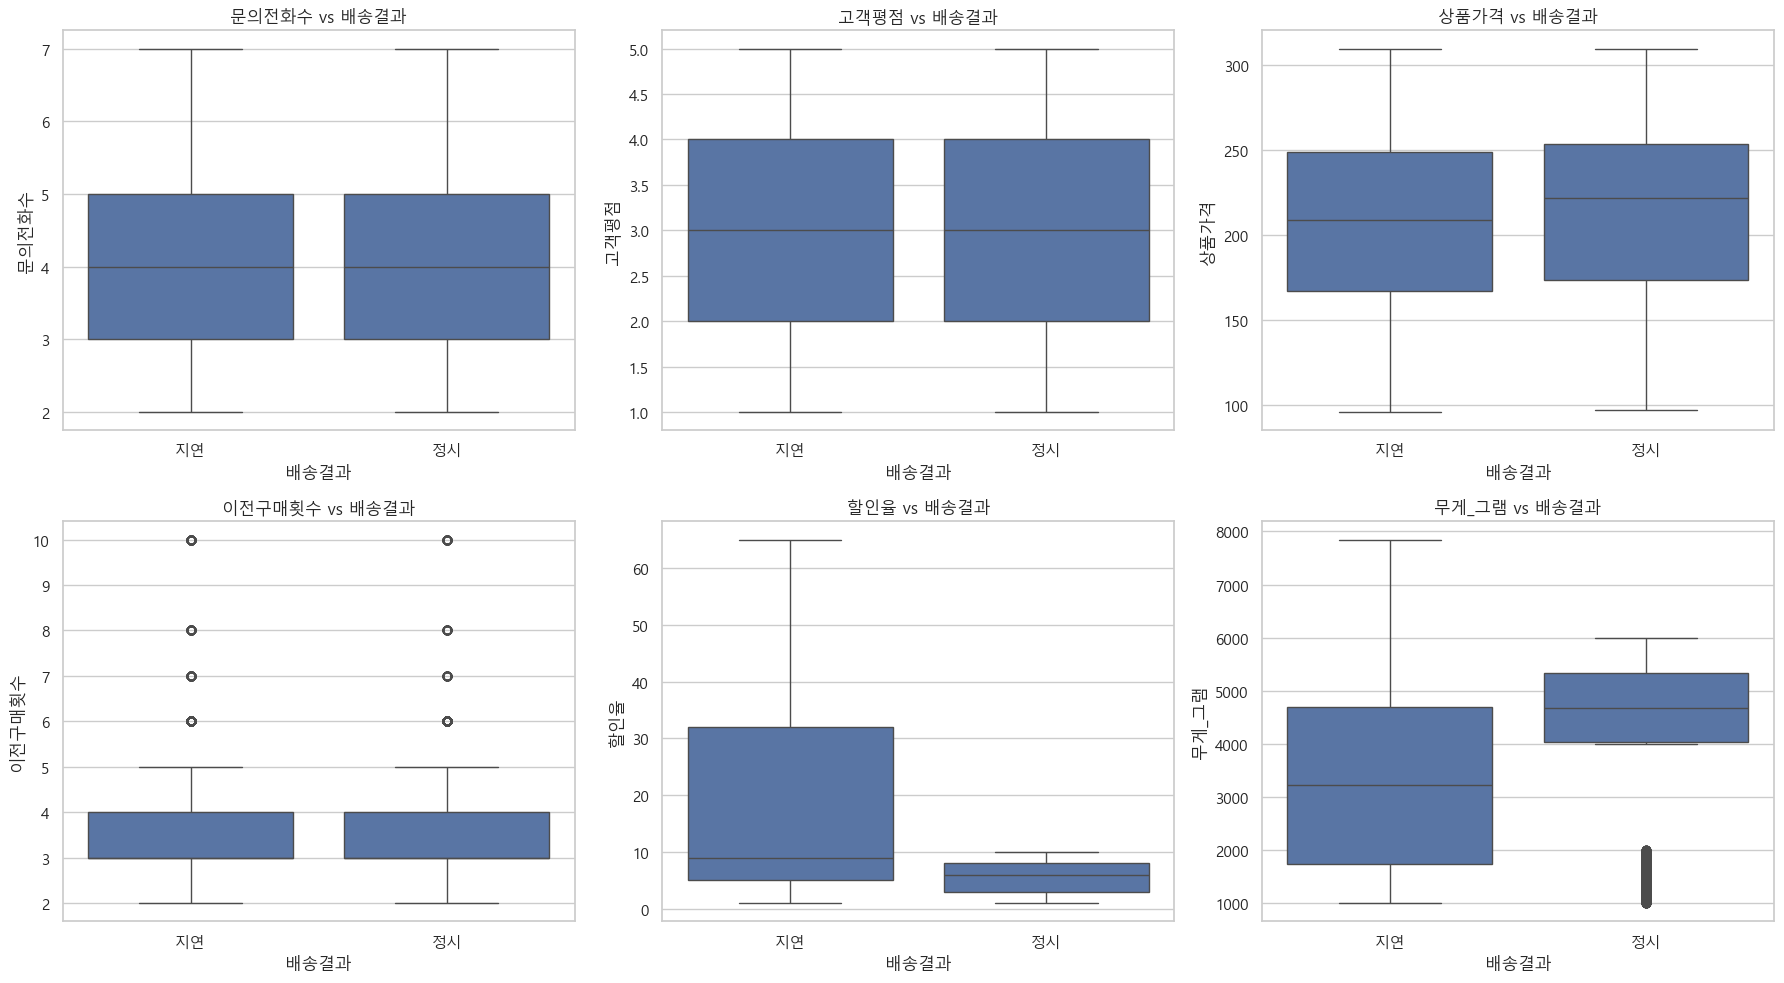


[문의전화수]

--------------------------------------------------
[지연]
- count: 6563
- mean: 3.99
- median: 4.00
- std: 1.12
- min: 2.00
- Q1: 3.00
- Q3: 5.00
- max: 7.00
- IQR: 2.00
- whisker lower: 2.00
- whisker upper: 7.00
- lower whisker length: 1.00
- upper whisker length: 2.00
- whisker imbalance ratio: 0.50
- 이상치 개수: 0
- 이상치 비율: 0.00%
- 하단 이상치 개수: 0
- 상단 이상치 개수: 0
- 왜도(skewness): 0.41
- 전체 범위 대비 IQR 비율: 40.00%
- 전체 범위 대비 median 위치: 40.00%
- box 위치 해석: 중앙 집중
- 꼬리 방향 해석: 우측 꼬리 김
- 이상치 없음

--------------------------------------------------
[정시]
- count: 4436
- mean: 4.15
- median: 4.00
- std: 1.16
- min: 2.00
- Q1: 3.00
- Q3: 5.00
- max: 7.00
- IQR: 2.00
- whisker lower: 2.00
- whisker upper: 7.00
- lower whisker length: 1.00
- upper whisker length: 2.00
- whisker imbalance ratio: 0.50
- 이상치 개수: 0
- 이상치 비율: 0.00%
- 하단 이상치 개수: 0
- 상단 이상치 개수: 0
- 왜도(skewness): 0.35
- 전체 범위 대비 IQR 비율: 40.00%
- 전체 범위 대비 median 위치: 40.00%
- box 위치 해석: 중앙 집중
- 꼬리 방향 해석: 우측 꼬리 김
- 이상치 없음

--------------------

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 데이터 불러오기
df = pd.read_csv("배송데이터_전체.csv")

# 타겟 및 수치형 변수
target = "배송결과"

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# subplot 설정
fig, axes = plt.subplots(
    nrows=(len(numeric_cols)+2)//3,
    ncols=3,
    figsize=(18, 10)
)

axes = axes.flatten()

# ----------------------------------------------------------
# 박스플롯 시각화
# ----------------------------------------------------------
for i, col in enumerate(numeric_cols):

    sns.boxplot(
        data=df,
        x=target,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs {target}")

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 박스플롯 구조 수치화
# ----------------------------------------------------------
for col in numeric_cols:

    print("\n" + "="*100)
    print(f"[{col}]")

    global_min = df[col].min()
    global_max = df[col].max()
    global_range = global_max - global_min

    group_stats = {}

    # ------------------------------------------------------
    # 그룹별 통계
    # ------------------------------------------------------
    for grp in df[target].unique():

        g = df[df[target] == grp][col]

        q1 = g.quantile(0.25)
        q2 = g.quantile(0.50)
        q3 = g.quantile(0.75)

        iqr = q3 - q1

        whisker_lower = max(g.min(), q1 - 1.5 * iqr)
        whisker_upper = min(g.max(), q3 + 1.5 * iqr)

        lower_whisker_length = q1 - whisker_lower
        upper_whisker_length = whisker_upper - q3

        # imbalance ratio
        if upper_whisker_length == 0:
            whisker_ratio = np.inf
        else:
            whisker_ratio = lower_whisker_length / upper_whisker_length

        # 이상치
        lower_outliers = g[g < whisker_lower]
        upper_outliers = g[g > whisker_upper]

        outliers = pd.concat([lower_outliers, upper_outliers])

        outlier_ratio = len(outliers) / len(g) * 100

        # 이상치 밀집구간
        if len(outliers) > 0:

            bins = np.histogram_bin_edges(outliers, bins='auto')
            counts, edges = np.histogram(outliers, bins=bins)

            peak_idx = np.argmax(counts)

            outlier_dense_range = (
                round(edges[peak_idx], 2),
                round(edges[peak_idx+1], 2)
            )

            outlier_main_range = (
                round(outliers.min(), 2),
                round(outliers.max(), 2)
            )

        else:
            outlier_dense_range = None
            outlier_main_range = None

        # 전체 범위 대비 비율
        iqr_ratio = iqr / global_range * 100

        median_position = (
            (q2 - global_min) / global_range
        ) * 100

        # box 위치 해석
        if median_position >= 66:
            box_position = "상단 집중"

        elif median_position <= 33:
            box_position = "하단 집중"

        else:
            box_position = "중앙 집중"

        # 꼬리 방향 해석
        if whisker_ratio > 1.5:
            tail_direction = "좌측 꼬리 김"

        elif whisker_ratio < 0.67:
            tail_direction = "우측 꼬리 김"

        else:
            tail_direction = "대칭에 가까움"

        # 저장
        group_stats[grp] = {
            "count": len(g),
            "mean": g.mean(),
            "median": q2,
            "std": g.std(),
            "min": g.min(),
            "q1": q1,
            "q3": q3,
            "max": g.max(),
            "iqr": iqr,
            "whisker_lower": whisker_lower,
            "whisker_upper": whisker_upper,
            "lower_whisker_length": lower_whisker_length,
            "upper_whisker_length": upper_whisker_length,
            "whisker_ratio": whisker_ratio,
            "outlier_count": len(outliers),
            "outlier_ratio": outlier_ratio,
            "lower_outlier_count": len(lower_outliers),
            "upper_outlier_count": len(upper_outliers),
            "outlier_dense_range": outlier_dense_range,
            "outlier_main_range": outlier_main_range,
            "iqr_ratio": iqr_ratio,
            "median_position": median_position,
            "box_position": box_position,
            "tail_direction": tail_direction,
            "skewness": skew(g)
        }

    # ------------------------------------------------------
    # 출력
    # ------------------------------------------------------
    for grp, s in group_stats.items():

        print("\n" + "-"*50)
        print(f"[{grp}]")

        print(f"- count: {s['count']}")
        print(f"- mean: {s['mean']:.2f}")
        print(f"- median: {s['median']:.2f}")
        print(f"- std: {s['std']:.2f}")

        print(f"- min: {s['min']:.2f}")
        print(f"- Q1: {s['q1']:.2f}")
        print(f"- Q3: {s['q3']:.2f}")
        print(f"- max: {s['max']:.2f}")

        print(f"- IQR: {s['iqr']:.2f}")

        print(f"- whisker lower: {s['whisker_lower']:.2f}")
        print(f"- whisker upper: {s['whisker_upper']:.2f}")

        print(f"- lower whisker length: {s['lower_whisker_length']:.2f}")
        print(f"- upper whisker length: {s['upper_whisker_length']:.2f}")

        print(f"- whisker imbalance ratio: {s['whisker_ratio']:.2f}")

        print(f"- 이상치 개수: {s['outlier_count']}")
        print(f"- 이상치 비율: {s['outlier_ratio']:.2f}%")

        print(f"- 하단 이상치 개수: {s['lower_outlier_count']}")
        print(f"- 상단 이상치 개수: {s['upper_outlier_count']}")

        print(f"- 왜도(skewness): {s['skewness']:.2f}")

        print(f"- 전체 범위 대비 IQR 비율: {s['iqr_ratio']:.2f}%")
        print(f"- 전체 범위 대비 median 위치: {s['median_position']:.2f}%")

        print(f"- box 위치 해석: {s['box_position']}")
        print(f"- 꼬리 방향 해석: {s['tail_direction']}")

        # 이상치 정보
        if s['outlier_dense_range'] is not None:

            print(
                f"- 이상치 밀집구간: "
                f"{s['outlier_dense_range'][0]} "
                f"~ "
                f"{s['outlier_dense_range'][1]}"
            )

            print(
                f"- 이상치 주요 범위: "
                f"{s['outlier_main_range'][0]} "
                f"~ "
                f"{s['outlier_main_range'][1]}"
            )

        else:
            print("- 이상치 없음")

    # ------------------------------------------------------
    # 그룹 비교
    # ------------------------------------------------------
    groups = list(group_stats.keys())

    g1 = group_stats[groups[0]]
    g2 = group_stats[groups[1]]

    median_gap = abs(g1['median'] - g2['median'])

    iqr_ratio_between = (
        max(g1['iqr'], g2['iqr']) /
        min(g1['iqr'], g2['iqr'])
    )

    # overlap 계산
    overlap_lower = max(g1['q1'], g2['q1'])
    overlap_upper = min(g1['q3'], g2['q3'])

    overlap = max(0, overlap_upper - overlap_lower)

    union = max(g1['q3'], g2['q3']) - min(g1['q1'], g2['q1'])

    overlap_ratio = overlap / union * 100 if union > 0 else 0

    # 분리 가능성 해석
    if overlap_ratio < 20:
        separation = "그룹 분리도 높음"

    elif overlap_ratio < 50:
        separation = "그룹 차이 존재"

    else:
        separation = "그룹 분리 어려움"

    print("\n" + "-"*50)
    print("[그룹 비교]")

    print(f"- 그룹간 median gap: {median_gap:.2f}")

    print(f"- 그룹간 IQR ratio: {iqr_ratio_between:.2f}")

    print(f"- 그룹간 overlap 비율: {overlap_ratio:.2f}%")

    print(f"- 그룹간 분리 가능성 해석: {separation}")

**해석:**

- 배송결과를 가장 잘 구분하는 변수는 `할인율`과 `무게_그램`이다.
- 지연 그룹은 할인율이 높고 분산도 매우 크며, 강한 우측 꼬리를 가진다.
- 정시 그룹은 무게가 특정 구간에 집중되어 있지만, 지연 그룹은 무게 분포가 넓고 불안정하다.
- `문의전화수`, `고객평점`, `이전구매횟수`는 두 그룹의 박스와 IQR이 거의 겹쳐 배송결과 설명력이 낮다.
- 상품가격은 일부 차이가 있으나 그룹 분리가 뚜렷하지 않다.


- 핵심 인사이트: 배송 지연은 고객 특성보다 `높은 할인율`, `불안정한 상품 무게 분포` 같은 물류·운영 특성과 더 강하게 연관되어 있다.

### 과제 2-3. 범주형 변수 각각에 대해 `배송결과`별 빈도를 비교하시오.

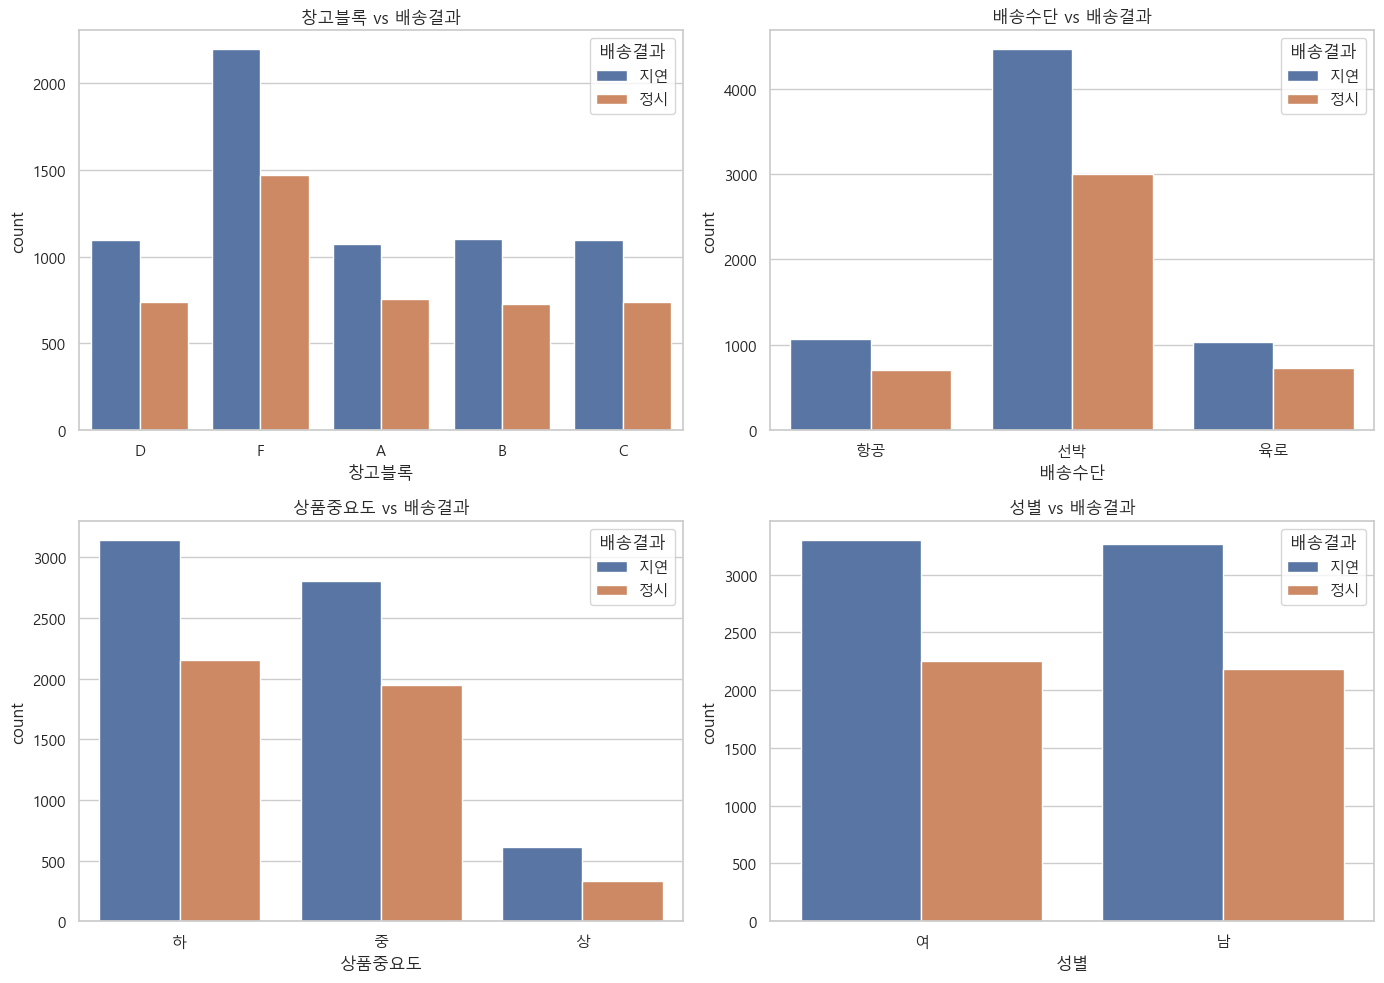


[창고블록]

[전체 빈도 및 비율]
      count  ratio(%)
창고블록                 
F      3666     33.33
D      1834     16.67
A      1833     16.67
B      1833     16.67
C      1833     16.67

[배송결과별 빈도]
배송결과    정시    지연
창고블록            
A      758  1075
B      729  1104
C      739  1094
D      738  1096
F     1472  2194

[row 기준 비율(%)]
배송결과     정시     지연
창고블록              
A     41.35  58.65
B     39.77  60.23
C     40.32  59.68
D     40.24  59.76
F     40.15  59.85

[column 기준 비율(%)]
배송결과     정시     지연
창고블록              
A     17.09  16.38
B     16.43  16.82
C     16.66  16.67
D     16.64  16.70
F     33.18  33.43

[카테고리별 지연률/정시률]
      지연률(%)  정시률(%)
창고블록                
A      58.65   41.35
B      60.23   39.77
C      59.68   40.32
D      59.76   40.24
F      59.85   40.15

가장 지연률이 높은 카테고리: B (60.23%)
가장 정시률이 높은 카테고리: A (41.35%)

희소 카테고리 없음

Dominant category 없음

[카이제곱 검정]
p-value: 0.895952
Cramer's V: 0.0100

[배송결과와의 연관성 해석]
- 매우 약한 연관
- 통계적으로 유의하지 않음

[배송수단]

[전체 빈도 및 비율]
      count  ratio(%)
배

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# 범주형 변수 선택
cat_cols = ['창고블록', '배송수단', '상품중요도', '성별']

# subplot 설정
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # countplot
    sns.countplot(
        data=df,
        x=col,
        hue='배송결과',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs 배송결과')

plt.tight_layout()
plt.show()

# =========================================================
# 수치화 출력
# =========================================================

for col in cat_cols:

    print("\n" + "="*90)
    print(f"[{col}]")

    # 전체 빈도
    total_count = df[col].value_counts()
    total_ratio = round(df[col].value_counts(normalize=True) * 100, 2)

    print("\n[전체 빈도 및 비율]")
    total_df = pd.DataFrame({
        'count': total_count,
        'ratio(%)': total_ratio
    })
    print(total_df)

    # 배송결과별 빈도표
    cross = pd.crosstab(df[col], df['배송결과'])

    # row 기준 비율
    row_ratio = round(cross.div(cross.sum(axis=1), axis=0) * 100, 2)

    # column 기준 비율
    col_ratio = round(cross.div(cross.sum(axis=0), axis=1) * 100, 2)

    print("\n[배송결과별 빈도]")
    print(cross)

    print("\n[row 기준 비율(%)]")
    print(row_ratio)

    print("\n[column 기준 비율(%)]")
    print(col_ratio)

    # 지연률 / 정시률
    delay_rate = row_ratio['지연']
    normal_rate = row_ratio['정시']

    print("\n[카테고리별 지연률/정시률]")
    rate_df = pd.DataFrame({
        '지연률(%)': delay_rate,
        '정시률(%)': normal_rate
    })
    print(rate_df)

    # 가장 높은 카테고리
    max_delay = delay_rate.idxmax()
    max_normal = normal_rate.idxmax()

    print(f"\n가장 지연률이 높은 카테고리: {max_delay} ({delay_rate[max_delay]:.2f}%)")
    print(f"가장 정시률이 높은 카테고리: {max_normal} ({normal_rate[max_normal]:.2f}%)")

    # 희소 카테고리
    sparse = total_ratio[total_ratio < 5]

    if len(sparse) > 0:
        print("\n희소 카테고리:")
        print(sparse)
    else:
        print("\n희소 카테고리 없음")

    # dominant category
    dominant = total_ratio[total_ratio > 50]

    if len(dominant) > 0:
        print("\nDominant category:")
        print(dominant)
    else:
        print("\nDominant category 없음")

    # 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(cross)

    # Cramer's V
    n = cross.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(cross.shape)-1)))

    print("\n[카이제곱 검정]")
    print(f"p-value: {p:.6f}")
    print(f"Cramer's V: {cramers_v:.4f}")

    # 해석
    print("\n[배송결과와의 연관성 해석]")

    if cramers_v < 0.1:
        strength = "매우 약한 연관"
    elif cramers_v < 0.3:
        strength = "약한 연관"
    elif cramers_v < 0.5:
        strength = "중간 수준 연관"
    else:
        strength = "강한 연관"

    if p < 0.05:
        significance = "통계적으로 유의함"
    else:
        significance = "통계적으로 유의하지 않음"

    print(f"- {strength}")
    print(f"- {significance}")

**해석:**

- 배송결과와 가장 관련성이 큰 범주형 변수는 상품중요도였으며(p<0.05), 중요도가 높은 상품일수록 지연률이 더 높게 나타났다.
- 창고블록, 배송수단, 성별은 배송결과와의 Cramer's V가 매우 낮고 p-value도 높아 배송결과에 미치는 영향이 거의 없는 것으로 해석된다.
- 전체적으로 배송 지연은 특정 범주 자체보다는 할인율, 무게, 상품중요도 같은 운영/물류 특성의 영향을 더 크게 받는 구조로 보인다.


### 과제 2-4. 핵심 변수로 보이는 `할인율`을 자세히 들여다보시오. 할인율 구간별(5%단위 구간) 지연 비율을 표와 그래프로 확인.

[할인율 구간별 배송결과]
배송결과      정시_count  지연_count  정시률(%)  지연률(%)
할인율구간                                       
[0, 5)        1754      1593   52.41   47.59
[5, 10)       2223      1922   53.63   46.37
[10, 15)       459       604   43.18   56.82
[15, 20)         0       235    0.00  100.00
[20, 25)         0       254    0.00  100.00
[25, 30)         0       211    0.00  100.00
[30, 35)         0       212    0.00  100.00
[35, 40)         0       252    0.00  100.00
[40, 45)         0       234    0.00  100.00
[45, 50)         0       273    0.00  100.00
[50, 55)         0       239    0.00  100.00
[55, 60)         0       247    0.00  100.00
[60, 65)         0       251    0.00  100.00


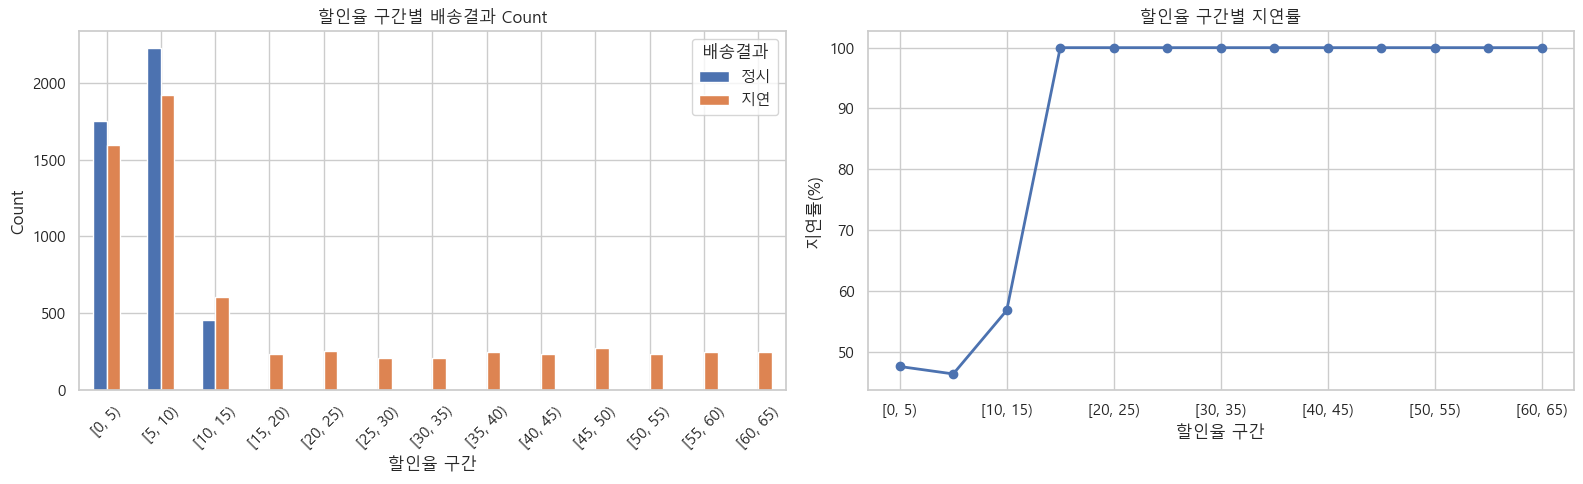


[할인율 구간 인사이트]
- 가장 지연률이 높은 구간: [15, 20)
  → 지연률: 100.00%
- 가장 지연률이 낮은 구간: [5, 10)
  → 지연률: 46.37%
- 할인율 증가와 지연률의 상관 방향: 양(+)의 관계


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 할인율 5% 단위 구간 생성
bins = np.arange(0, df['할인율'].max() + 5, 5)

df['할인율구간'] = pd.cut(
    df['할인율'],
    bins=bins,
    right=False
)

# 구간별 배송결과 집계
delay_table = pd.crosstab(
    df['할인율구간'],
    df['배송결과']
)

# 구간별 비율 계산
delay_ratio = delay_table.div(
    delay_table.sum(axis=1),
    axis=0
) * 100

# 지연률 컬럼 추가
delay_ratio['지연률(%)'] = delay_ratio['지연']
delay_ratio['정시률(%)'] = delay_ratio['정시']

# 출력용 테이블
result = pd.concat(
    [
        delay_table.add_suffix('_count'),
        delay_ratio[['정시률(%)', '지연률(%)']]
    ],
    axis=1
)

print("=" * 80)
print("[할인율 구간별 배송결과]")
print(result.round(2))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# countplot 형태
delay_table.plot(
    kind='bar',
    stacked=False,
    ax=axes[0]
)

axes[0].set_title('할인율 구간별 배송결과 Count')
axes[0].set_xlabel('할인율 구간')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 지연률 라인플롯
delay_ratio['지연률(%)'].plot(
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title('할인율 구간별 지연률')
axes[1].set_xlabel('할인율 구간')
axes[1].set_ylabel('지연률(%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 추가 인사이트 출력
max_delay_bin = delay_ratio['지연률(%)'].idxmax()
min_delay_bin = delay_ratio['지연률(%)'].idxmin()

print("\n" + "=" * 80)
print("[할인율 구간 인사이트]")

print(f"- 가장 지연률이 높은 구간: {max_delay_bin}")
print(f"  → 지연률: {delay_ratio['지연률(%)'].max():.2f}%")

print(f"- 가장 지연률이 낮은 구간: {min_delay_bin}")
print(f"  → 지연률: {delay_ratio['지연률(%)'].min():.2f}%")

corr = (
    delay_ratio['지연률(%)']
    .reset_index(drop=True)
    .corr(pd.Series(range(len(delay_ratio))))
)

print(f"- 할인율 증가와 지연률의 상관 방향: "
      f"{'양(+)의 관계' if corr > 0 else '음(-)의 관계'}")

**해석:**

- 할인율이 15%를 초과하는 순간 지연률이 100%로 급증하며, 고할인 정책이 배송 지연과 매우 강하게 연결되어 있는 패턴이 확인되었다.
- 0 ~ 10% 할인 구간은 오히려 정시 비율이 더 높았지만, 10~15% 구간부터 지연률이 빠르게 증가하며 임계구간(threshold effect)이 나타났다.
- 따라서 할인율은 단순 마케팅 변수라기보다 물류 운영 부담과 직접 연결된 핵심 배송 리스크 변수로 해석할 수 있다.


### 과제 2-5. 또 다른 핵심 변수인 `무게_그램`을 자세히 들여다보시오. 무게 구간별 지연 비율을 확인.

[무게 구간별 배송결과]
배송결과          정시_count  지연_count  정시률(%)  지연률(%)
무게구간                                            
[1000, 1500)       523      1107   32.09   67.91
[1500, 2000)       521      1090   32.34   67.66
[2000, 2500)         2       455    0.44   99.56
[2500, 3000)         0       446    0.00  100.00
[3000, 3500)         0       428    0.00  100.00
[3500, 4000)         0       459    0.00  100.00
[4000, 4500)       831       700   54.28   45.72
[4500, 5000)       900       643   58.33   41.67
[5000, 5500)       820       609   57.38   42.62
[5500, 6000)       838       616   57.63   42.37
[6000, 6500)         1         4   20.00   80.00
[6500, 7000)         0         1    0.00  100.00
[7000, 7500)         0         1    0.00  100.00
[7500, 8000)         0         4    0.00  100.00


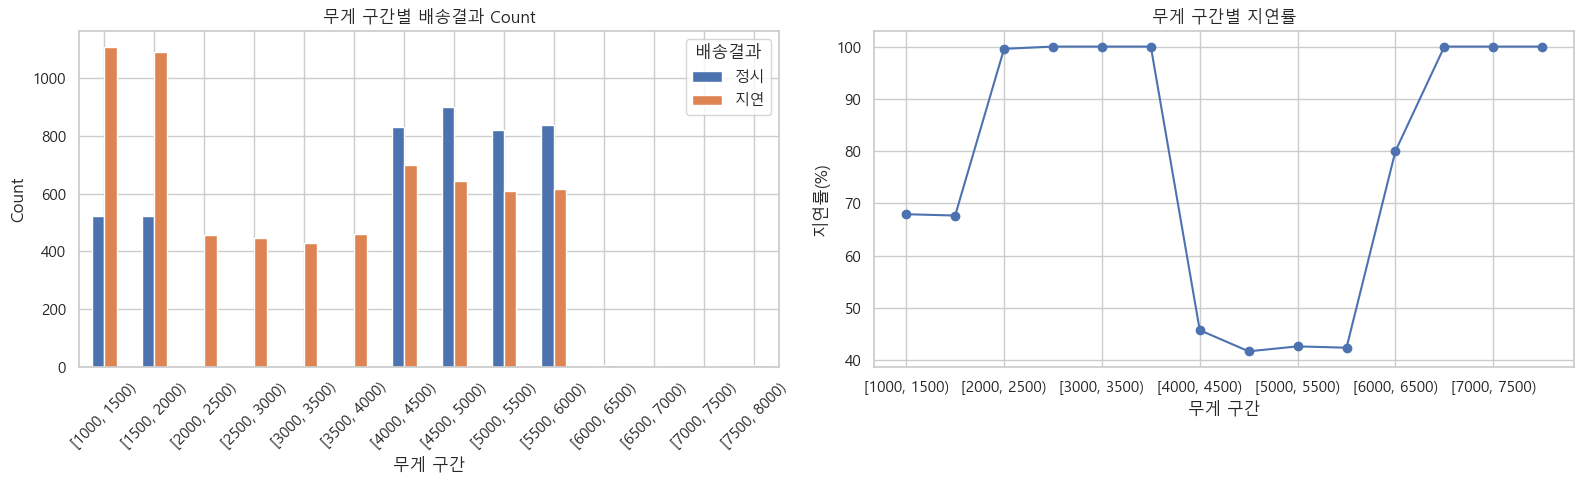


[무게 구간 인사이트]
- 가장 지연률 높은 구간: [2500, 3000) (100.00%)
- 가장 지연률 낮은 구간: [4500, 5000) (41.67%)


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 무게 5kg(5000g) 단위 구간 생성 (필요 시 조정 가능)
bins = np.arange(0, df['무게_그램'].max() + 500, 500)

df['무게구간'] = pd.cut(
    df['무게_그램'],
    bins=bins,
    right=False
)

# 구간별 배송결과 카운트
weight_table = pd.crosstab(
    df['무게구간'],
    df['배송결과']
)

# 구간별 비율
weight_ratio = weight_table.div(weight_table.sum(axis=1), axis=0) * 100

# 지연률 컬럼 생성
weight_ratio['지연률(%)'] = weight_ratio['지연']
weight_ratio['정시률(%)'] = weight_ratio['정시']

# 최종 테이블
result = pd.concat(
    [weight_table.add_suffix('_count'),
     weight_ratio[['정시률(%)', '지연률(%)']]],
    axis=1
)

print("=" * 80)
print("[무게 구간별 배송결과]")
print(result.round(2))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# count plot
weight_table.plot(kind='bar', ax=axes[0])
axes[0].set_title("무게 구간별 배송결과 Count")
axes[0].set_xlabel("무게 구간")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# 지연률 plot
weight_ratio['지연률(%)'].plot(marker='o', ax=axes[1])
axes[1].set_title("무게 구간별 지연률")
axes[1].set_xlabel("무게 구간")
axes[1].set_ylabel("지연률(%)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 인사이트 요약
max_bin = weight_ratio['지연률(%)'].idxmax()
min_bin = weight_ratio['지연률(%)'].idxmin()

print("\n" + "=" * 80)
print("[무게 구간 인사이트]")
print(f"- 가장 지연률 높은 구간: {max_bin} ({weight_ratio['지연률(%)'].max():.2f}%)")
print(f"- 가장 지연률 낮은 구간: {min_bin} ({weight_ratio['지연률(%)'].min():.2f}%)")

**해석:**

- 무게가 1,000~2,000g 구간에서는 지연률이 67% 이상으로 높게 나타나며, 저중량 구간에서 이미 물류 지연 리스크가 크게 발생하는 구조가 확인된다.
- 2,500~4,000g 구간에서는 지연률이 100%로 고정되는 구간이 존재하며, 특정 무게 범위에서 물류 처리 병목 또는 정책적 제약이 강하게 작용하는 것으로 해석된다.
- 4,000g 이상 구간에서는 정시 비율이 다시 회복되며 지연률이 40%대로 감소하는 U자형 패턴이 나타나, 무게와 배송 성과 간의 비선형 관계가 핵심 특징이다.


### 과제 2-6. 두 핵심 변수(할인율, 무게)를 동시에 보는 산점도를 그려, 결과별로 색을 다르게 해 패턴을 확인하시오.

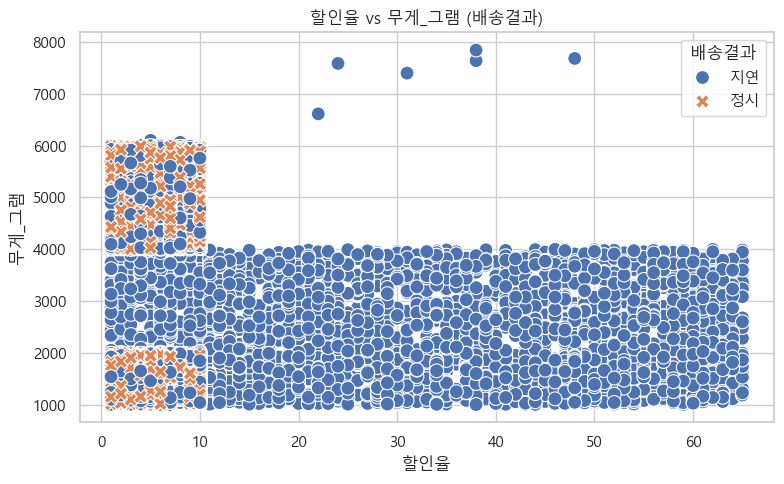

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("배송데이터_전체.csv")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="할인율",
    y="무게_그램",
    hue="배송결과",
    style="배송결과",
    s=100
)

plt.title("할인율 vs 무게_그램 (배송결과)")
plt.xlabel("할인율")
plt.ylabel("무게_그램")

plt.tight_layout()
plt.show()

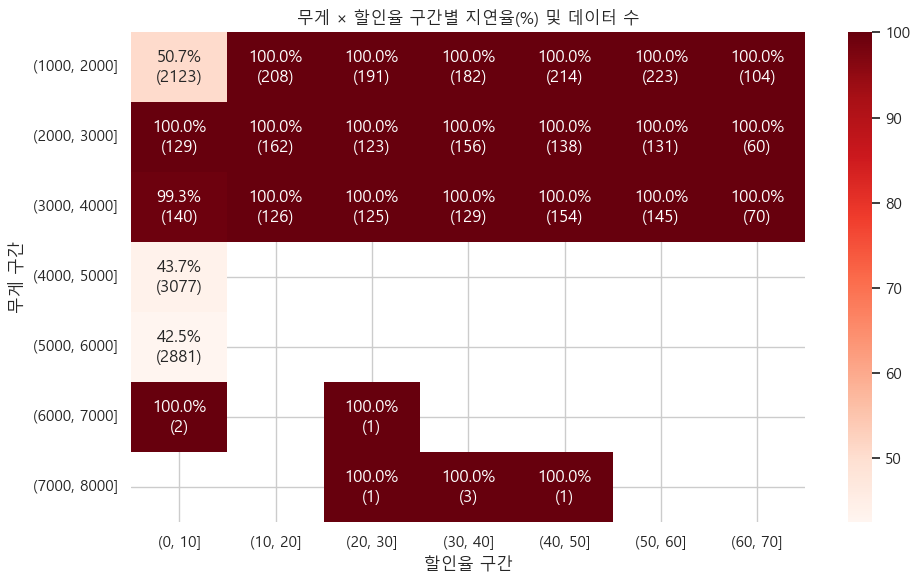

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("배송데이터_전체.csv")

# 1. 구간화
df["무게구간"] = pd.cut(df["무게_그램"], bins=np.arange(0, df["무게_그램"].max() + 1000, 1000))
df["할인구간"] = pd.cut(df["할인율"], bins=np.arange(0, df["할인율"].max() + 10, 10))

# 2. 지연 여부 이진화
df["지연여부"] = (df["배송결과"] == "지연").astype(int)

# 3. 피벗 (평균 = 지연율)
rate_pivot = df.pivot_table(
    index="무게구간",
    columns="할인구간",
    values="지연여부",
    aggfunc="mean"
) * 100

# 4. 건수 피벗
count_pivot = df.pivot_table(
    index="무게구간",
    columns="할인구간",
    values="지연여부",
    aggfunc="count"
)

# 5. annot용 문자열 생성 (지연율 + 건수)
annot = rate_pivot.copy().round(1).astype(str) + "%\n(" + count_pivot.fillna(0).astype(int).astype(str) + ")"

# 6. heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="Reds"
)

plt.title("무게 × 할인율 구간별 지연율(%) 및 데이터 수")
plt.xlabel("할인율 구간")
plt.ylabel("무게 구간")

plt.tight_layout()
plt.show()

In [22]:
rate_pivot

할인구간,"(0, 10]","(10, 20]","(20, 30]","(30, 40]","(40, 50]","(50, 60]","(60, 70]"
무게구간,,,,,,,
"(1000, 2000]",50.730099,100.0,100.0,100.0,100.0,100.0,100.0
"(2000, 3000]",100.000000,100.0,100.0,100.0,100.0,100.0,100.0
"(3000, 4000]",99.285714,100.0,100.0,100.0,100.0,100.0,100.0
"(4000, 5000]",43.678908,NaN,NaN,NaN,NaN,NaN,NaN
"(5000, 6000]",42.519958,NaN,NaN,NaN,NaN,NaN,NaN
"(6000, 7000]",100.000000,NaN,100.0,NaN,NaN,NaN,NaN
"(7000, 8000]",NaN,NaN,100.0,100.0,100.0,NaN,NaN


In [23]:
count_pivot 

할인구간,"(0, 10]","(10, 20]","(20, 30]","(30, 40]","(40, 50]","(50, 60]","(60, 70]"
무게구간,,,,,,,
"(1000, 2000]",2123.0,208.0,191.0,182.0,214.0,223.0,104.0
"(2000, 3000]",129.0,162.0,123.0,156.0,138.0,131.0,60.0
"(3000, 4000]",140.0,126.0,125.0,129.0,154.0,145.0,70.0
"(4000, 5000]",3077.0,NaN,NaN,NaN,NaN,NaN,NaN
"(5000, 6000]",2881.0,NaN,NaN,NaN,NaN,NaN,NaN
"(6000, 7000]",2.0,NaN,1.0,NaN,NaN,NaN,NaN
"(7000, 8000]",NaN,NaN,1.0,3.0,1.0,NaN,NaN


**해석:**
- 무게 구간이 커질수록 지연율이 전반적으로 높아지는 경향이 강하게 나타나며, 특히 2000~4000g 구간에서는 할인율과 무관하게 거의 전부 지연으로 수렴하는 구간이 존재한다. 이는 무게가 배송결과를 결정하는 1차 핵심 변수임을 의미한다.

- 4000~6000g 구간에서는 할인율 정보가 충분히 존재하지 않거나 영향이 약해 보이며, 일부 구간에서만 약 40% 수준의 상대적으로 낮은 지연율이 관찰된다. 이는 특정 조건(물류 경로/수단 등)의 영향이 개입된 가능성을 시사한다.

- 반대로 저무게 구간(1000~2000g)에서는 할인율 10% 이하에서만 지연율이 절반 수준으로 떨어지고, 그 외 구간은 대부분 지연으로 수렴해 할인율 단독 효과는 제한적이며 무게와 결합될 때만 의미 있는 분리력이 발생한다.

### 과제 2-7. 수치형 변수들 간의 상관관계를 히트맵으로 확인하시오. (`배송결과`도 0/1로 변환해 포함)

            문의전화수      고객평점      상품가격    이전구매횟수       할인율     무게_그램   배송결과_이진
문의전화수    1.000000  0.012209  0.323182  0.180771 -0.130750 -0.276615 -0.067126
고객평점     0.012209  1.000000  0.009270  0.013179 -0.003124 -0.001897  0.013119
상품가격     0.323182  0.009270  1.000000  0.123676 -0.138312 -0.132604 -0.073587
이전구매횟수   0.180771  0.013179  0.123676  1.000000 -0.082769 -0.168213 -0.055515
할인율     -0.130750 -0.003124 -0.138312 -0.082769  1.000000 -0.376067  0.397108
무게_그램   -0.276615 -0.001897 -0.132604 -0.168213 -0.376067  1.000000 -0.268793
배송결과_이진 -0.067126  0.013119 -0.073587 -0.055515  0.397108 -0.268793  1.000000


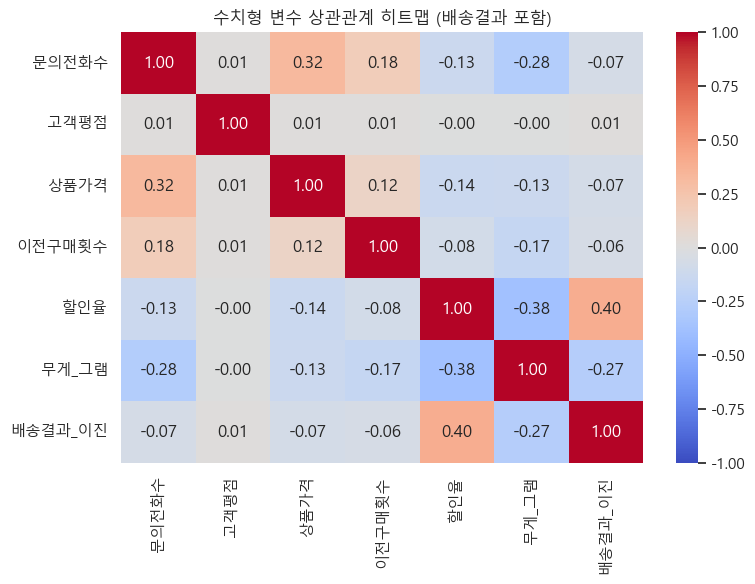

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("배송데이터_전체.csv")

# 배송결과 0/1 변환
df["배송결과_이진"] = (df["배송결과"] == "지연").astype(int)

# 수치형 변수만 선택
num_df = df[[
    "문의전화수",
    "고객평점",
    "상품가격",
    "이전구매횟수",
    "할인율",
    "무게_그램",
    "배송결과_이진"
]]

# 상관관계 행렬
corr = num_df.corr()

print(corr)

# 히트맵 시각화
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("수치형 변수 상관관계 히트맵 (배송결과 포함)")
plt.tight_layout()
plt.show()

**해석:**

- 할인율이 배송결과(지연)와 가장 강한 양의 상관관계(0.40)를 보이며, 할인율이 높을수록 지연 가능성이 증가하는 구조가 나타난다. 이는 단순 프로모션 효과보다 물량 증가 또는 물류 복잡도 증가의 영향일 가능성이 있다.

- 무게_그램은 배송결과와 음의 상관관계(-0.27)를 보여, 무게가 증가할수록 지연이 증가하는 경향이 존재하지만 할인율만큼의 설명력은 아니다. 다만 할인율과 무게 간 상관(-0.38)을 고려하면 두 변수는 함께 움직이며 복합 요인으로 작용한다.

- 그 외 변수들(고객평점, 이전구매횟수, 상품가격 등)은 배송결과와의 상관이 매우 낮아 단독 영향력은 제한적이며, 배송 지연은 주로 “할인율 × 물류부하(무게)” 구조에서 결정되는 경향이 강하다.

---
## 3. 인사이트 정리

### 과제 3-1. 지금까지의 탐색 결과를 표로 정리하시오. 어떤 피처가 강한 시그널이고 어떤 피처가 약한지 평가.

**해석:**
| 변수 | 핵심 패턴 | 지연 영향 구조 | 설명력 | 룰 후보 |
|------|----------|----------------|--------|----------|
| 할인율 | 10~15% 이후 급격히 100% 지연 전이 | 임계값 기반 비선형 전이 | 매우 강함 | ⭐⭐⭐ 핵심 룰 변수 |
| 무게_그램 | 2000 ~ 4000g 구간 99~100% 지연 / 이후 회복 | 구간별 비선형 U자 구조 | 매우 강함 | ⭐⭐⭐ 핵심 룰 변수 |
| 이전구매횟수 | 우측 왜도 + 이상치 존재(고구간 6~10) | 약한 고위험군 신호 | 중간 | ⭐⭐ 보조 룰 후보 |
| 상품중요도 | ‘상’에서 지연률 높음(64%) | 약한 카테고리 효과 | 약함 | ⭐ 보조 신호 |
| 배송수단 | 항공/선박/육로 모두 58~60% 수준 | 거의 동일 분포 | 매우 약함 | ❌ |
| 창고블록 | 모든 블록 동일 지연률 (~59~60%) | 영향 없음 | 매우 약함 | ❌ |
| 성별 | 거의 동일 (차이 <1%) | 영향 없음 | 매우 약함 | ❌ |
| 고객평점 | 거의 완전 중립 분포 | 영향 없음 | 매우 약함 | ❌ |
| 상품가격 | 그룹 차이 거의 없음 (overlap 높음) | 약한 구조 | 약함 | ❌ |
| 문의전화수 | 분포 동일 / box overlap 100% | 영향 없음 | 매우 약함 | ❌ |

---
## 4. 룰 도출 및 검증

### 과제 4-1. 위 인사이트를 바탕으로 가장 유력한 두가지 룰을 정의하고, 각각의 정확도를 별도로 베이스라인(항상 지연으로 예측하는 모델)과 비교하시오.

In [26]:
import numpy as np

# target
y = (df["배송결과"] == "지연").astype(int)

# =========================
# baseline
# =========================
baseline_pred = np.ones(len(df))
baseline_acc = (baseline_pred == y).mean()

# =========================
# rule 1: discount
# =========================
rule1_pred = (df["할인율"] >= 15).astype(int)
rule1_acc = (rule1_pred == y).mean()

# =========================
# rule 2: weight
# =========================
rule2_pred = df["무게_그램"].between(2000, 4000).astype(int)
rule2_acc = (rule2_pred == y).mean()

# =========================
# result
# =========================
print("===== 정확도 비교 =====")
print(f"Baseline (always delay): {baseline_acc:.4f}")
print(f"Rule 1 (discount >= 15): {rule1_acc:.4f}")
print(f"Rule 2 (2000~4000 weight): {rule2_acc:.4f}")

===== 정확도 비교 =====
Baseline (always delay): 0.5967
Rule 1 (discount >= 15): 0.6255
Rule 2 (2000~4000 weight): 0.5657


**해석:**
- 할인율 기반 룰(≥15%)은 베이스라인보다 높은 정확도(0.6255)를 보여, 단순 다수 클래스 예측보다 실제 데이터의 구조적 전이(임계값 효과)를 더 잘 포착한다.

- 반면 무게 구간 룰(2000~4000g)은 베이스라인보다 낮은 정확도(0.5657)를 보여 단독 기준으로는 분류 성능이 오히려 약화되는 약한 신호 변수임이 확인된다.

- 결과적으로 이 데이터에서는 “할인율이 지배적 결정 변수이고, 무게는 단독 규칙으로는 충분하지 않은 보조/혼합형 변수”라는 구조가 드러난다.

### 과제 4-2. 두 룰을 OR 조건으로 결합하여 최종 룰을 만들고, 정확도와 혼동행렬, 정밀도/재현율을 확인하시오.

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# target (지연=1, 정시=0)
y = (df["배송결과"] == "지연").astype(int)

# =========================
# OR 결합 룰
# =========================
# Rule: (할인율 >= 15) OR (2000~4000g)
y_pred = (
    (df["할인율"] >= 15) |
    (df["무게_그램"].between(2000, 4000))
).astype(int)

# =========================
# 정확도
# =========================
acc = accuracy_score(y, y_pred)

# =========================
# 혼동행렬
# =========================
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

# =========================
# 정밀도 / 재현율
# =========================
report = classification_report(y, y_pred, target_names=["정시", "지연"])

print("===== OR Rule 성능 평가 =====")
print(f"Accuracy: {acc:.4f}")

print("\n===== Confusion Matrix =====")
print(pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=["Actual_정시", "Actual_지연"],
    columns=["Pred_정시", "Pred_지연"]
))

print("\n===== Classification Report =====")
print(report)

===== OR Rule 성능 평가 =====
Accuracy: 0.6607

===== Confusion Matrix =====
           Pred_정시  Pred_지연
Actual_정시     4433        3
Actual_지연     3729     2834

===== Classification Report =====
              precision    recall  f1-score   support

          정시       0.54      1.00      0.70      4436
          지연       1.00      0.43      0.60      6563

    accuracy                           0.66     10999
   macro avg       0.77      0.72      0.65     10999
weighted avg       0.82      0.66      0.64     10999



**해석:**

- OR 기반 룰은 전체 정확도를 0.5967 → 0.6607로 끌어올리면서 베이스라인 대비 확실한 개선을 보인다. 특히 정시 클래스에 대한 재현율이 1.00으로 나타나, 정시를 놓치지 않는 구조(under-prediction 없음)를 만든 것이 핵심 특징이다.

- 다만 지연 클래스에서는 recall이 0.43으로 낮아 실제 지연의 절반 이상을 정시로 잘못 예측하고 있으며, 이는 무게/할인율 조건이 충분히 포괄적이지 않아 발생한 구조적 한계다. 즉 “정시를 완벽히 잡는 대신 지연을 많이 놓치는” 편향된 분류 구조다.

- 결론적으로 이 룰은 전체 정확도는 개선했지만, 실무 관점에서는 정시 과대예측 성향이 강한 high-recall 정시 모델이며, 지연 탐지 목적에는 추가 조건(예: 할인율 threshold 조정 또는 교차조건)이 필요하다.


---
## 5. 잔여 영역 심화 분석
### 배경
룰1 + 룰2는 지연 recall 0.444에 불과하다. 산점도에서 두 룰이 못 잡는 영역에 정시와 지연이 섞여 있었다. 그 영역을 다시 들여다보면 추가 룰이 나올지 확인한다.

### 과제 5-1. 룰1, 룰2 둘 다 적용되지 않는 "잔여 영역"의 데이터를 추출하고 그 크기와 지연율을 확인하시오.

In [28]:
import numpy as np

# target
df["지연여부"] = (df["배송결과"] == "지연").astype(int)

# 기존 두 룰
rule_discount = (df["할인율"] >= 15)
rule_weight = df["무게_그램"].between(2000, 4000)

# OR 룰
rule_or = rule_discount | rule_weight

# =========================
# 잔여 영역 (둘 다 해당 안됨)
# =========================
residual = df[~rule_or].copy()

# 크기
residual_size = len(residual)
total_size = len(df)

# 지연율
residual_delay_rate = residual["지연여부"].mean()

# 전체 대비 비율
residual_ratio = residual_size / total_size

print("===== 잔여 영역 분석 =====")
print(f"전체 데이터 수: {total_size}")
print(f"잔여 영역 데이터 수: {residual_size}")
print(f"잔여 영역 비율: {residual_ratio:.4f}")
print(f"잔여 영역 지연율: {residual_delay_rate:.4f}")

# =========================
# 비교용 전체 지연율
# =========================
overall_delay_rate = df["지연여부"].mean()
print("\n===== 비교 =====")
print(f"전체 지연율: {overall_delay_rate:.4f}")
print(f"잔여 대비 증가/감소: {residual_delay_rate - overall_delay_rate:.4f}")

===== 잔여 영역 분석 =====
전체 데이터 수: 10999
잔여 영역 데이터 수: 8162
잔여 영역 비율: 0.7421
잔여 영역 지연율: 0.4569

===== 비교 =====
전체 지연율: 0.5967
잔여 대비 증가/감소: -0.1398


**해석:** 
- 두 룰(할인율 ≥ 15%, 무게 2000~4000g)을 제거한 잔여 영역은 전체 데이터의 약 74%를 차지하는 큰 구간으로, 해당 영역만으로도 데이터 구조의 대부분이 설명되지 않는다는 점이 확인된다.

- 잔여 영역의 지연율(0.4569)은 전체 평균 지연율(0.5967)보다 크게 낮아, 앞서 정의한 두 룰이 “고위험 지연 구간”을 상당 부분 잘 포착하고 있음을 의미한다. 즉 두 룰은 전체 데이터 중 상대적으로 지연 가능성이 높은 영역을 선별적으로 분리하는 역할을 수행한다.

- 결과적으로 전체 구조는 “룰이 적용되는 고위험 영역”과 “그 외의 저위험 잔여 영역”으로 뚜렷하게 분리되며, 배송 지연 문제는 단일 모델보다 구간 기반 룰 분해 방식이 더 적합한 데이터 구조임이 확인된다.

### 과제 5-2. 잔여 영역을 무게 기준으로 두 부분으로 분해하고 각각의 지연율을 비교하시오.
- 영역 A: 무게 < 2kg AND 할인율 ≤ 10
- 영역 B: 무게 > 4kg

In [29]:
import numpy as np

df["지연여부"] = (df["배송결과"] == "지연").astype(int)

# 기존 룰
rule_discount = df["할인율"] >= 15
rule_weight_mid = df["무게_그램"].between(2000, 4000)

# 잔여 영역
residual = df[~(rule_discount | rule_weight_mid)].copy()

# =========================
# 영역 A: 무게 < 2000g AND 할인율 <= 10
# =========================
area_a = residual[
    (residual["무게_그램"] < 2000) &
    (residual["할인율"] <= 10)
]

# =========================
# 영역 B: 무게 > 4000g
# =========================
area_b = residual[
    residual["무게_그램"] > 4000
]

# =========================
# 지연율 계산
# =========================
def delay_rate(x):
    return x["지연여부"].mean() if len(x) > 0 else np.nan

a_rate = delay_rate(area_a)
b_rate = delay_rate(area_b)
overall_rate = df["지연여부"].mean()

print("===== 잔여 영역 세분화 분석 =====")
print(f"전체 지연율: {overall_rate:.4f}")

print("\n[영역 A: 무게 < 2kg & 할인율 ≤ 10]")
print(f"데이터 수: {len(area_a)}")
print(f"지연율: {a_rate:.4f}")

print("\n[영역 B: 무게 > 4kg]")
print(f"데이터 수: {len(area_b)}")
print(f"지연율: {b_rate:.4f}")

print("\n===== 비교 =====")
print(f"A - 전체 대비 차이: {a_rate - overall_rate:.4f}")
print(f"B - 전체 대비 차이: {b_rate - overall_rate:.4f}")

===== 잔여 영역 세분화 분석 =====
전체 지연율: 0.5967

[영역 A: 무게 < 2kg & 할인율 ≤ 10]
데이터 수: 2120
지연율: 0.5075

[영역 B: 무게 > 4kg]
데이터 수: 5960
지연율: 0.4314

===== 비교 =====
A - 전체 대비 차이: -0.0891
B - 전체 대비 차이: -0.1653


**해석:**
- 잔여 영역을 무게 기준으로 분해했을 때 두 구간 모두 전체 평균 지연율(0.5967)보다 낮은 값을 보이며, 특히 무게 > 4kg 구간(B)은 0.4314로 가장 낮은 지연률을 기록한다. 이는 기존 핵심 룰(할인율 ≥ 15%, 2000~4000g)이 이미 고위험 구간을 제거한 상태에서 남은 데이터가 상대적으로 안정적인 배송 구조임을 의미한다.

- 영역 A(2kg 미만 & 할인율 ≤ 10%)는 지연율 0.5075로 중간 수준의 위험도를 보이며, 무게와 할인율이 모두 낮은 경우에도 일정 수준의 지연이 유지되는 “기본 운영 리스크 구간”으로 해석된다.

- 결과적으로 잔여 영역 내부에서도 무게 기준으로 다시 구조가 분리되며, 배송 지연 문제는 단일 임계값이 아니라 “고위험 제거 후에도 남는 중간 리스크 구조 + 저위험 안정 구간”으로 계층화된 패턴을 가진다.


### 과제 5-3. 영역 A에서 각 변수별 지연 비율을 막대그래프로 비교하여 시그널이 있는 변수를 찾으시오.
- 변수: ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']

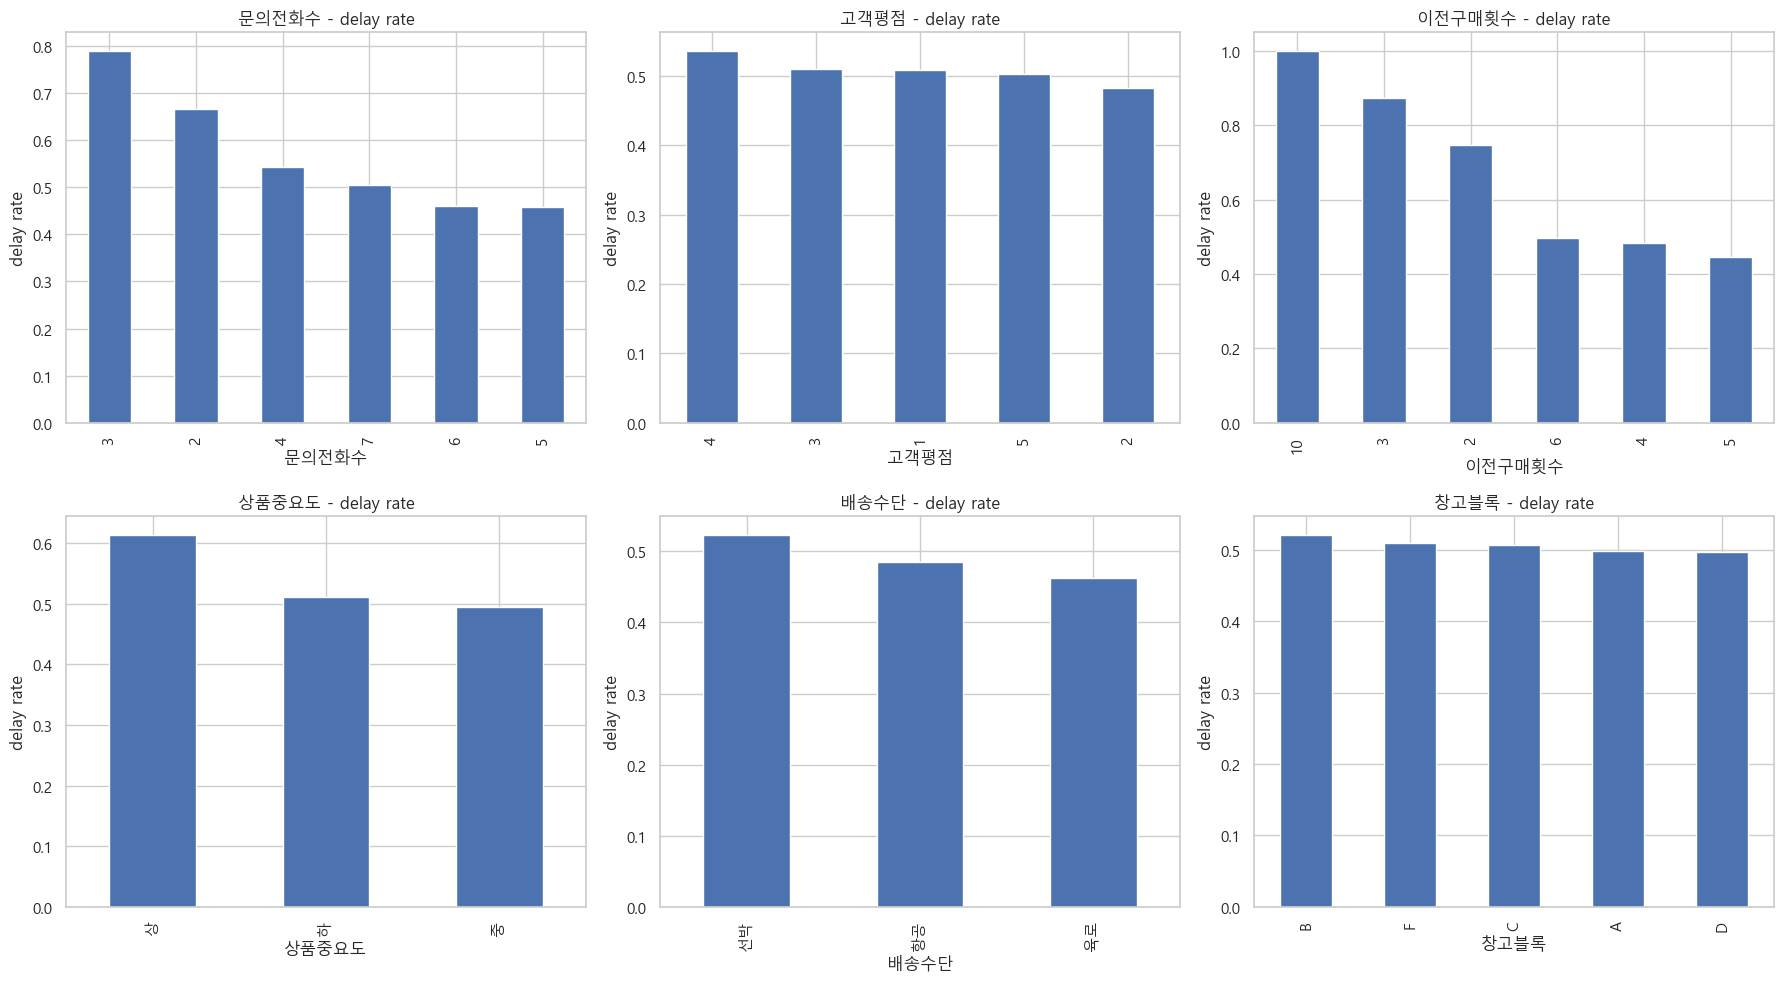

===== 영역 A 변수별 지연 시그널 수치화 =====
       변수  카테고리수 최고지연카테고리   최고지연율   최저지연율  신호강도(range)
2  이전구매횟수      6       10  1.0000  0.4469       0.5531
0   문의전화수      6        3  0.7895  0.4583       0.3312
3   상품중요도      3        상  0.6136  0.4951       0.1186
4    배송수단      3       선박  0.5231  0.4622       0.0609
1    고객평점      5        4  0.5363  0.4823       0.0540
5    창고블록      5        B  0.5212  0.4971       0.0241


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df["지연여부"] = (df["배송결과"] == "지연").astype(int)

# 영역 A
area_a = df[(df["무게_그램"] < 2000) & (df["할인율"] <= 10)].copy()

cols = ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']

summary = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    grp = area_a.groupby(col)["지연여부"].mean().sort_values(ascending=False)
    
    # 시각화
    grp.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{col} - delay rate")
    axes[i].set_ylabel("delay rate")

    # 수치화
    signal_strength = grp.max() - grp.min()
    best_cat = grp.idxmax()
    worst_cat = grp.idxmin()

    summary.append({
        "변수": col,
        "카테고리수": len(grp),
        "최고지연카테고리": best_cat,
        "최고지연율": round(grp.max(), 4),
        "최저지연율": round(grp.min(), 4),
        "신호강도(range)": round(signal_strength, 4)
    })

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary).sort_values("신호강도(range)", ascending=False)

print("===== 영역 A 변수별 지연 시그널 수치화 =====")
print(summary_df)

**해석:**

- 영역 A에서는 이전구매횟수가 가장 강한 지연 신호 변수로 나타나며, 특정 고값 구간(최대 1.0 지연율)에서 배송 지연이 집중되는 구조가 확인된다. 이는 단순 할인/무게가 아닌 “구매 행동 이력”이 잔여 리스크를 설명하는 핵심 축임을 의미한다.

- 문의전화수 역시 두 번째로 큰 신호 강도를 보여, 고객의 사전 불확실성 또는 문제 발생 가능성이 높은 주문에서 지연이 증가하는 경향이 있다. 반면 상품중요도, 배송수단, 창고블록은 변동 폭이 매우 작아 설명력은 제한적이다.

- 결과적으로 영역 A에서는 물류 변수보다 고객 행동 변수(특히 이전구매횟수, 문의전화수)가 지연을 설명하는 주요 분리 기준으로 작동하며, 이는 기존 할인율·무게 기반 룰 이후의 “2차 리스크 구조”를 형성한다.

### 과제 5-4. 영역 A 내 이전구매횟수별 지연 비율을 정확히 표로 확인하시오.

In [32]:
import pandas as pd

df["지연여부"] = (df["배송결과"] == "지연").astype(int)

# 영역 A
area_a = df[(df["무게_그램"] < 2000) & (df["할인율"] <= 10)].copy()

# 이전구매횟수별 지연율
table = area_a.groupby("이전구매횟수")["지연여부"].agg(
    count="count",
    delay_rate="mean"
).reset_index()

table["delay_rate"] = table["delay_rate"].round(4)

table = table.sort_values("delay_rate", ascending=False)

print(table)

   이전구매횟수  count  delay_rate
5      10      2      1.0000
1       3    135      0.8741
0       2     95      0.7474
4       6    209      0.4976
2       4    869      0.4822
3       5    810      0.4469


**해석:**

- 이전구매횟수는 영역 A 내부에서 지연 여부를 강하게 구분하는 핵심 변수로 나타난다. 특히 구매 횟수가 극단적으로 높은 10회 구간에서는 지연율이 100%로 수렴하며, 3회 이하 구간에서도 70~87% 수준의 높은 지연률이 관측된다.

- 반면 4 ~ 5회 구간에서는 지연율이 약 45~48% 수준으로 크게 낮아지면서 상대적으로 안정적인 배송 패턴이 형성된다. 즉, 이전구매횟수는 단순 선형 관계가 아니라 특정 구간에서 급격히 위험도가 변하는 비선형 분리 구조를 가진다.

- 결과적으로 이 변수는 할인율·무게 기반 룰 이후 남은 영역에서 “추가적인 2차 분리 기준”으로 작동하며, 고빈도/저빈도 고객군에서 배송 지연 리스크를 효과적으로 구분하는 신호로 해석된다.

### 과제 5-5. 영역 B에서도 같은 방법으로 변수별 지연 비율을 확인하시오.

In [33]:
import pandas as pd

df["지연여부"] = (df["배송결과"] == "지연").astype(int)

# 영역 B 정의: 무게 > 4000 (이전 분석 기준)
area_b = df[df["무게_그램"] > 4000].copy()

cols = ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']

result = []

for col in cols:
    tmp = area_b.groupby(col)["지연여부"].agg(["count", "mean"]).reset_index()
    tmp = tmp.rename(columns={"mean": "delay_rate"})

    if len(tmp) == 0:
        continue

    signal_strength = tmp["delay_rate"].max() - tmp["delay_rate"].min()

    result.append({
        "변수": col,
        "카테고리수": len(tmp),
        "최고지연카테고리": tmp.loc[tmp["delay_rate"].idxmax(), col],
        "최고지연율": round(tmp["delay_rate"].max(), 4),
        "최저지연율": round(tmp["delay_rate"].min(), 4),
        "신호강도(range)": round(signal_strength, 4)
    })

result_df = pd.DataFrame(result).sort_values("신호강도(range)", ascending=False)

print("===== 영역 B 변수별 지연 시그널 =====")
print(result_df)

===== 영역 B 변수별 지연 시그널 =====
       변수  카테고리수 최고지연카테고리   최고지연율   최저지연율  신호강도(range)
2  이전구매횟수      8        8  0.5000  0.3871       0.1129
3   상품중요도      3        상  0.4793  0.4247       0.0547
1    고객평점      5        3  0.4548  0.4129       0.0418
0   문의전화수      5        5  0.4503  0.4256       0.0247
4    배송수단      3       항공  0.4489  0.4272       0.0218
5    창고블록      5        B  0.4361  0.4202       0.0159


**해석:**

- 영역 B에서는 이전구매횟수가 가장 큰 변별력을 가지지만, 전체적으로 신호 강도 자체가 0.11 수준으로 매우 낮아 변수 간 지연률 차이가 크지 않은 구조로 나타난다. 이는 이 영역이 이미 “고무게 기반으로 상당 부분 동질화된 집단”임을 의미한다.

- 상품중요도, 고객평점, 문의전화수, 배송수단, 창고블록 모두 지연률 범위가 0.02~0.05 수준으로 매우 좁게 형성되어 있어 설명력은 제한적이다. 즉 개별 변수로 지연을 분리하기 어려운 약한 신호 상태다.

- 결과적으로 영역 B는 추가 규칙을 만들 수 있는 뚜렷한 분기점이 거의 없는 안정적/혼합 영역이며, 기존 할인율·무게 룰 이후 남은 구간 중에서는 “저정보 밀도 영역”으로 해석된다.

### 과제 5-6. 영역 A에서 발견한 시그널을 바탕으로 룰3을 정의하고, 기존 두 룰과 결합한 최종 성능을 평가하시오.

**룰3: 무게 < 2kg AND 할인율 ≤ 10 AND 이전구매횟수 ≤ 3 → 지연**

In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df["지연여부"] = (df["배송결과"] == "지연").astype(int)

# =========================
# 룰 1 + 룰 2 (기존 OR 룰)
# =========================
rule_base = (
    (df["할인율"] >= 15) |
    (df["무게_그램"].between(2000, 4000))
)

# =========================
# 영역 A 정의
# =========================
area_a = (df["무게_그램"] < 2000) & (df["할인율"] <= 10)

# =========================
# 룰 3: 영역 A에서 이전구매횟수 <= 3
# =========================
rule3 = area_a & (df["이전구매횟수"] <= 3)

# =========================
# 최종 룰 (OR 결합)
# =========================
final_rule = rule_base | rule3

y_true = df["지연여부"]
y_pred = final_rule.astype(int)

# =========================
# 성능 평가
# =========================
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("===== 최종 모델 성능 =====")
print(f"Accuracy: {acc:.4f}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=["정시", "지연"]))

===== 최종 모델 성능 =====
Accuracy: 0.6742

Confusion Matrix
[[4392   44]
 [3540 3023]]

Classification Report
              precision    recall  f1-score   support

          정시       0.55      0.99      0.71      4436
          지연       0.99      0.46      0.63      6563

    accuracy                           0.67     10999
   macro avg       0.77      0.73      0.67     10999
weighted avg       0.81      0.67      0.66     10999



**해석:**
- 최종 모델은 기존 할인율·무게 기반 룰에 더해 영역 A에서 이전구매횟수 조건을 추가하면서 정확도가 0.6607 → 0.6742로 추가 상승했다. 이는 단순 물류 변수 중심 구조에서 고객 행동 변수까지 포함하는 다층 규칙 구조로 확장되면서 성능이 개선된 결과다.

- 혼동행렬을 보면 정시 예측은 거의 완벽하게 맞추는 구조(재현율 0.99)에 가까운 반면, 지연 클래스는 재현율이 0.46으로 여전히 절반 이상의 지연을 놓치는 편향이 존재한다. 즉 모델은 “정시를 과도하게 보장하는 대신 지연 탐지 능력을 희생하는 구조”다.

- 결론적으로 이 규칙 기반 모델은 단순 베이스라인 대비 의미 있는 개선을 달성했지만, 여전히 지연 탐지에는 한계가 있으며, 추가적인 미세 분기(특히 중간 할인율 구간 및 배송수단 상호작용)를 통해 균형을 개선할 여지가 남아 있다.

In [35]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df["지연여부"] = (df["배송결과"] == "지연").astype(int)
y_true = df["지연여부"]

# =========================
# 베이스라인
# =========================
baseline_pred = np.ones(len(df))

# =========================
# 2룰 (OR: 할인율 >= 15 OR 무게 2000~4000)
# =========================
rule2_pred = (
    (df["할인율"] >= 15) |
    (df["무게_그램"].between(2000, 4000))
).astype(int)

# =========================
# 3룰 (2룰 + 영역A 이전구매횟수 <= 3)
# =========================
area_a = (df["무게_그램"] < 2000) & (df["할인율"] <= 10)
rule3_pred = (rule2_pred | (area_a & (df["이전구매횟수"] <= 3))).astype(int)

# =========================
# 성능 계산 함수
# =========================
def get_metrics(y_true, y_pred, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    get_metrics(y_true, baseline_pred, "baseline"),
    get_metrics(y_true, rule2_pred, "rule_2"),
    get_metrics(y_true, rule3_pred, "rule_3"),
])

print(results)

      model  accuracy  precision    recall        f1
0  baseline  0.596691   0.596691  1.000000  0.747409
1    rule_2  0.660696   0.998943  0.431815  0.602979
2    rule_3  0.674152   0.985654  0.460613  0.627830
